<a href="https://colab.research.google.com/github/31manishapandey/Intrusiondet-Intrusion-Detection-System/blob/main/Intrusiondet_DeepLearning_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install tensorflow scikit-learn pandas numpy matplotlib seaborn flask joblib pyngrok

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
from google.colab import files
uploaded = files.upload()

Saving sample_dataset.csv to sample_dataset.csv


In [4]:
import pandas as pd
import numpy as np

import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("sample_dataset.csv")

print(df.shape)
df.head()

(450060, 42)


,Header_Length,Protocol Type,Time_To_Live,Rate,fin_flag_number,syn_flag_number,rst_flag_number,psh_flag_number,ack_flag_number,ece_flag_number,...,Max,AVG,Std,Tot size,IAT,Number,Variance,flow_id,Label,flow_time_bin
0,19.8,6,63.36,2123.676722,0.0,0.99,0.0,0.0,0.0,0.0,...,60,60.00,0.000000,60.00,0.000471,100,0.000000e+00,255,6.0,0
1,0.0,47,64.00,3826.012077,0.0,0.00,0.0,0.0,0.0,0.0,...,592,592.00,0.000000,592.00,0.000263,100,0.000000e+00,313,11.0,0
2,20.0,6,64.00,22124.190315,0.0,1.00,0.0,0.0,0.0,0.0,...,60,60.00,0.000000,60.00,0.000045,100,0.000000e+00,395,4.0,0
3,32.0,6,93.50,13774.397373,0.0,0.00,0.0,0.4,1.0,0.0,...,2858,1043.20,1149.288553,1043.20,0.000091,10,1.320864e+06,712,10.0,0
4,8.0,17,64.64,26390.889071,0.0,0.00,0.0,0.0,0.0,0.0,...,86,60.26,2.600000,60.26,0.000038,100,6.760000e+00,1182,1.0,0


In [6]:
X = df.drop("Label", axis=1)
y = df["Label"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [7]:
X_train = np.expand_dims(X_train, axis=2)
X_test = np.expand_dims(X_test, axis=2)

print(X_train.shape)

(360048, 41, 1)


In [8]:
input_shape = X_train.shape[1]

inputs = Input(shape=(input_shape,1))

# CNN Feature Extraction
x = Conv1D(64,3,activation='relu')(inputs)
x = MaxPooling1D(2)(x)

x = Conv1D(128,3,activation='relu')(x)
x = MaxPooling1D(2)(x)

# Transformer Attention
attention = MultiHeadAttention(
    num_heads=4,
    key_dim=64
)(x,x)

x = Add()([x,attention])
x = LayerNormalization()(x)

x = GlobalAveragePooling1D()(x)

x = Dense(128,activation='relu')(x)
x = Dropout(0.3)(x)

outputs = Dense(len(np.unique(y)),activation='softmax')(x)

model = Model(inputs,outputs)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 41, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 39, 64)    │        256 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 19, 64)    │          0 │ conv1d[0][0]      │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 17, 128)   │     24,704 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 8, 128)    │          0 │ conv1d_1[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 8, 128)    │    131,968 │ max_pooling1d_1[… │
│ (MultiHeadAttentio… │                   │            │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 8, 128)    │          0 │ max_pooling1d_1[… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 8, 128)    │        256 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     16,512 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 34)        │      4,386 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 178,082 (695.63 KB)

 Trainable params: 178,082 (695.63 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=256,
    validation_split=0.2
)

Epoch 1/50
1126/1126 ━━━━━━━━━━━━━━━━━━━━ 222s 197ms/step - accuracy: 0.7183 - loss: 0.5793 - val_accuracy: 0.7359 - val_loss: 0.5137
Epoch 2/50
1126/1126 ━━━━━━━━━━━━━━━━━━━━ 243s 180ms/step - accuracy: 0.7386 - loss: 0.5090 - val_accuracy: 0.7455 - val_loss: 0.5021
Epoch 3/50
1126/1126 ━━━━━━━━━━━━━━━━━━━━ 201s 179ms/step - accuracy: 0.7437 - loss: 0.4973 - val_accuracy: 0.7503 - val_loss: 0.4911
Epoch 4/50
1126/1126 ━━━━━━━━━━━━━━━━━━━━ 207s 184ms/step - accuracy: 0.7449 - loss: 0.4895 - val_accuracy: 0.7445 - val_loss: 0.4862
Epoch 5/50
1126/1126 ━━━━━━━━━━━━━━━━━━━━ 265s 187ms/step - accuracy: 0.7485 - loss: 0.4835 - val_accuracy: 0.7460 - val_loss: 0.4863
Epoch 6/50
1126/1126 ━━━━━━━━━━━━━━━━━━━━ 250s 176ms/step - accuracy: 0.7492 - loss: 0.4801 - val_accuracy: 0.7517 - val_loss: 0.4822
Epoch 7/50
1126/1126 ━━━━━━━━━━━━━━━━━━━━ 204s 178ms/step - accuracy: 0.7505 - loss: 0.4789 - val_accuracy: 0.7522 - val_loss: 0.4796
Epoch 8/50
1126/1126 ━━━━━━━━━━━━━━━━━━━━ 201s 177ms/step - ac

In [11]:
pred = model.predict(X_test)

predicted_labels = np.argmax(pred,axis=1)

print(classification_report(y_test,predicted_labels))

2813/2813 ━━━━━━━━━━━━━━━━━━━━ 17s 6ms/step
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     13863
         1.0       0.74      0.91      0.81     10381
         2.0       0.68      0.88      0.76      8557
         3.0       1.00      1.00      1.00      7828
         4.0       0.49      0.49      0.49      7751
         5.0       1.00      1.00      1.00      7704
         6.0       0.48      0.65      0.55      6896
         7.0       0.75      0.47      0.58      6349
         8.0       0.60      0.31      0.41      5147
         9.0       0.63      0.22      0.32      3887
        10.0       0.75      0.86      0.80      2120
        11.0       0.99      0.98      0.99      1876
        12.0       0.98      1.00      0.99      1681
        13.0       0.98      0.99      0.98      1427
        14.0       0.99      0.98      0.99       871
        15.0       0.50      0.65      0.56       712
        16.0       0.66      0.62    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [20]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

pred = model.predict(X_test)
predicted_labels = np.argmax(pred, axis=1)

accuracy = accuracy_score(y_test, predicted_labels)
precision = precision_score(y_test, predicted_labels, average='weighted')
recall = recall_score(y_test, predicted_labels, average='weighted')
f1 = f1_score(y_test, predicted_labels, average='weighted')

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall (Detection Rate):", recall)
print("F1 Score:", f1)

2813/2813 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step
Accuracy: 0.777740745678354
Precision: 0.7793274835341775
Recall (Detection Rate): 0.777740745678354
F1 Score: 0.7651786503516695


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


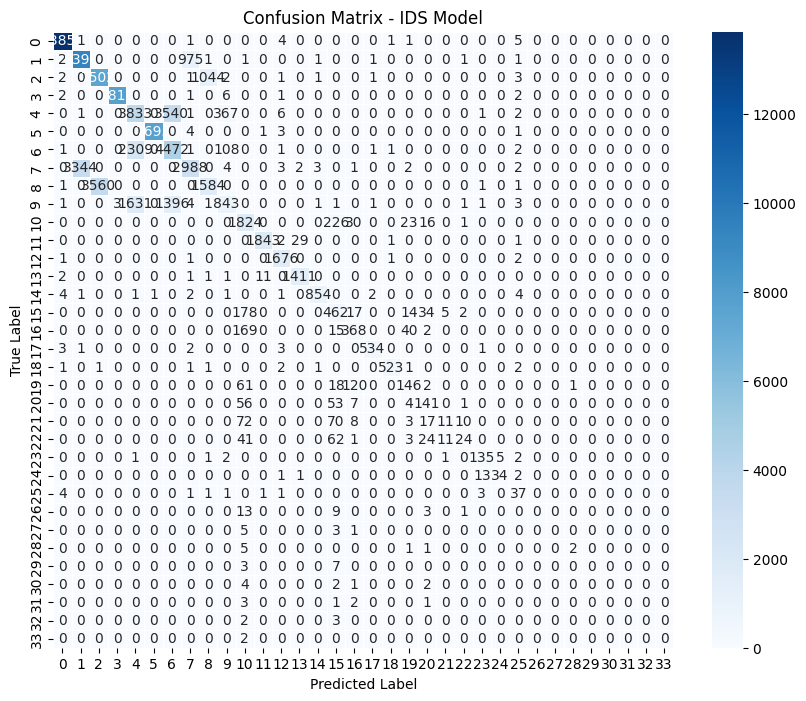

In [29]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_test, predicted_labels)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    linewidths=0.5,
    cbar=True
)

plt.title("Confusion Matrix - IDS Model")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

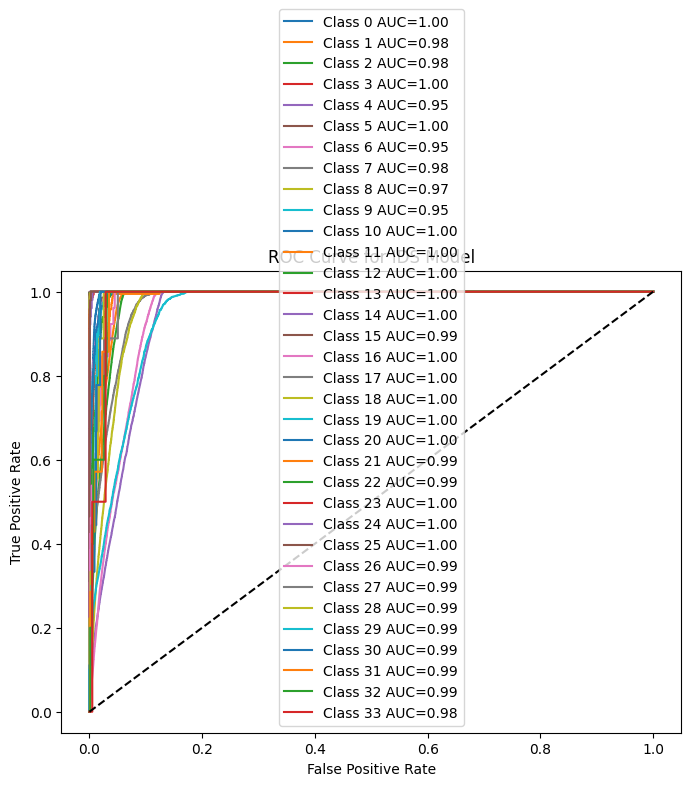

In [22]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test, classes=np.unique(y_test))

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(y_test_bin.shape[1]):

    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8,6))

for i in range(len(roc_auc)):
    plt.plot(fpr[i], tpr[i], label="Class %d AUC=%0.2f"%(i, roc_auc[i]))

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for IDS Model")
plt.legend()

plt.show()

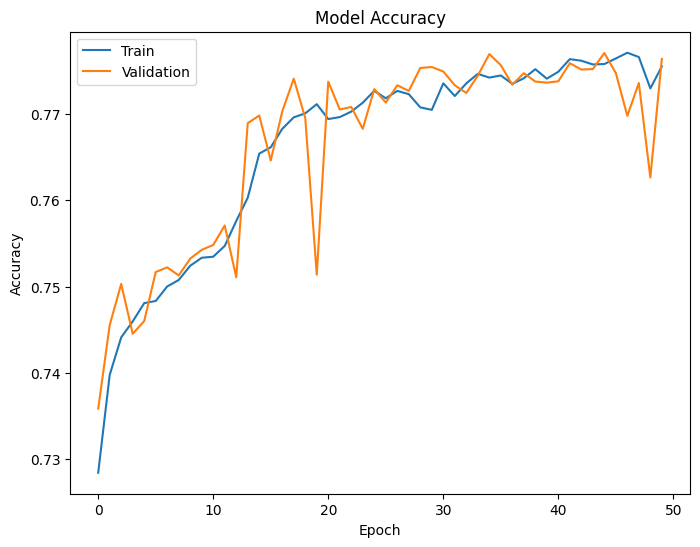

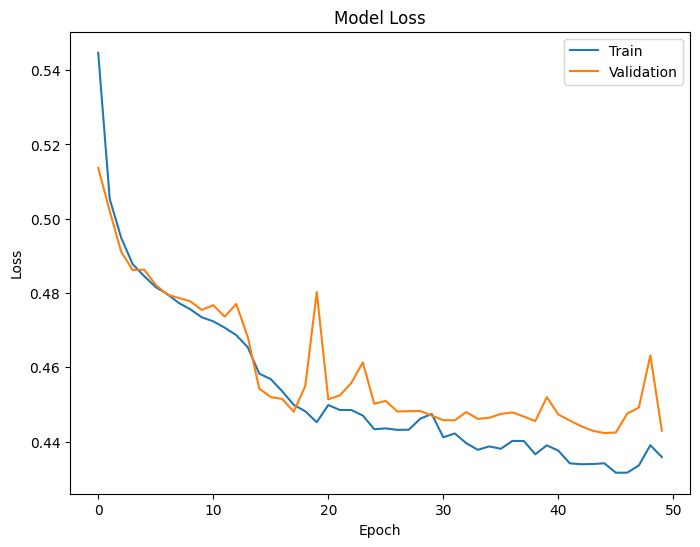

In [34]:
plt.figure(figsize=(8,6))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.legend(['Train','Validation'])

plt.show()
plt.figure(figsize=(8,6))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')

plt.legend(['Train','Validation'])

plt.show()

In [27]:
detection_rate = recall_score(y_test, predicted_labels, average='weighted')

print("Detection Rate:", detection_rate)

Detection Rate: 0.777740745678354


In [28]:
fp = cm.sum(axis=0) - np.diag(cm)
tn = cm.sum() - (fp + np.diag(cm) + (cm.sum(axis=1) - np.diag(cm)))

false_positive_rate = fp / (fp + tn)

print("False Positive Rate per class:", false_positive_rate)

False Positive Rate per class: [3.15171572e-04 4.20439276e-02 4.37173900e-02 3.65034557e-05
 4.79206428e-02 1.21494873e-05 5.93868810e-02 1.19049042e-02
 1.23725918e-02 5.71262700e-03 6.99722387e-03 1.47499319e-04
 3.28310559e-04 3.61234972e-04 7.85272770e-05 5.26315789e-03
 2.10248496e-03 6.70630840e-05 4.47032265e-05 1.02605282e-03
 1.13649025e-03 1.89265317e-04 1.89212653e-04 2.22556056e-04
 5.55796401e-05 3.89048831e-04 0.00000000e+00 0.00000000e+00
 1.11107408e-05 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00]


In [35]:
model.save("IDS_Intrusiondet_model.h5")

In [46]:
from google.colab import files
files.download("IDS_Intrusiondet_model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>